**Investments: Theory and Data Analysis**, Bates, Boyer, and Fletcher

# Chapter 6: Ken French Portfolio Returns with `farms`

In this notebook, we move from simulated returns to observed historical returns. We use the `farms` Python package and its `load_ken_french_data()` function to download Ken French strategy portfolios from the [Kenneth French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html). We begin with monthly size deciles, then compare deciles, quintiles, strategy types, and available portfolio frequencies before estimating summary statistics and plotting return histories.

## Learning objectives

By the end of this notebook, you should be able to:

- Install and import the `farms` package.
- Explain how portfolio sorts group firms by a characteristic.
- Download monthly decile and quintile portfolios with `farms`.
- Use `load_ken_french_data()` with different data types, strategies, portfolio selections, and frequencies.
- Explain which strategies have published daily portfolio files.
- Estimate historical mean return and volatility for strategy portfolios.
- Annualize monthly estimates.
- Calculate portfolio excess returns and compare annualized Sharpe ratios across size deciles.
- Plot a return distribution and the growth of one dollar invested.
- Explain why historical summary statistics are sample estimates rather than known population parameters.

## What is a portfolio sort?

A portfolio sort ranks firms by a characteristic, divides them into groups, and calculates the return on each group. For example, the Ken French size decile portfolios sort firms by market equity into 10 portfolios: `Dec 1` is the portfolio that contains the firms with the lowest market equity, while `Dec 10` contains the firms with the highest market equity. The portfolios are eithier value- or equal-weighted, depending on which option you choose.

The sort is formed using the breakpoints and timing specified by the Ken French data library. A breakpoint is a cutoff value for the sorting characteristic that determines which portfolio a stock belongs to. For example, when forming size deciles, Ken French calculates the 10th, 20th, through 90th percentiles of market capitalization using all NYSE firms. Firms below the 10th-percentile cutoff are assigned to `Dec 1` firms between the 10th and 20th percentiles to `Dec 2`, and so forth. These breakpoints are then applied to all eligible stocks, not just NYSE stocks, and are recalculated according to the library’s specified schedule, such as annually in June or monthly.

## Imports and setup

We install `farms` from PyPI and import the packages used in the analysis.

In [1]:
%pip install -q farms

import farms as fm
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd

# Keep displayed tables compact and readable.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

Note: you may need to restart the kernel to use updated packages.


## Available portfolio sorts



The current package supports the following portfolio sorts:

| Sort name | Characteristic used to form portfolios |
| --- | --- |
| `accruals` | Operating working-capital accruals |
| `beta` | Historical market beta |
| `booktomarket` | Book equity relative to market equity (BE/ME) |
| `dividendyield` | Dividend yield (D/P) |
| `earningsprice` | Earnings relative to price (E/P) |
| `idiosyncraticvariance` | Residual-return variance from the Fama--French three-factor model |
| `investment` | Change in total assets relative to lagged total assets |
| `momentum` | Prior returns from months t-12 through t-2 |
| `netissuances` | Net share issuance |
| `profitability` | Operating profitability |
| `shorttermreversal` | Prior one-month return |
| `size` | Market equity |
| `variance` | Variance of daily returns |


## Accessing Portfolio-Sorted Returns
The `load_ken_french_data()` function provides access to a variety of historical return data posted on his website. Here we describe how to access returns for portfolios sorted on firm characteristics described above.  The inputs below allow you to specify the portfolio grouping, sorting strategy, weighting method, frequency, sample period, and particular portfolios to retrieve.

**Required inputs:**
- `data_type`: Choose the portfolio granularity:
  - `deciles` divide stocks into 10 portfolios, labeled `Dec 1` through `Dec 10`.
  - `quintiles` divide stocks into 5 portfolios, labeled `Qnt 1` through `Qnt 5`.
- `strategy`: Select the characteristic used to sort stocks.  Available strategies are listed above.

**Optional inputs:**

- `weighting`: Choose `value` or `equal` weighting; defaults to `value`.
- `portfolio`: Select all portfolios or specific groups; defaults to `all`.
  - `all`: Return every portfolio.
  - An integer: Return one portfolio, such as `portfolio=1`.
  - A list or tuple of integers: Return selected portfolios, such as `portfolio=[1, 5, 10]`.
  - For deciles, valid portfolio numbers are 1 through 10. For quintiles, valid portfolio numbers are 1 through 5.
  - `'low'`: Return the lowest-ranked portfolio.
  - `'high'`: Return the highest-ranked portfolio.
- `frequency`: Request monthly or daily data when published for the selected strategy; defaults to `monthly`.
- `start_date` and `end_date`: Define the sample period; defaults to the full available range.
- `details`: Display detailed information about the selected source and request; defaults to `False`.

Note that not all strategy/data_type/frequency combinations are available. The `load_ken_french_data()` function will raise an error if you request a combination that is not available.  The bottom of the error message explains the invalid combination and lists the available options.  The `available` DataFrame below shows all available combinations of strategy, data_type, and frequency.

In [2]:
# Example: List the available data for size portfolios.
available = fm.list_ken_french_data()
available[available["strategy"] == "size"]

,strategy,title,data_type,frequency,dataset
25,size,Size,deciles,monthly,Portfolios_Formed_on_ME
26,size,Size,quintiles,monthly,Portfolios_Formed_on_ME
27,size,Size,deciles,daily,Portfolios_Formed_on_ME_Daily


## Examples

In [3]:
# Example 1: Load all available monthly value-weighted size decile portfolio returns and market factors.
size_deciles = fm.load_ken_french_data(
    data_type='deciles',
    strategy='size',
    include_factors='market'
)
size_deciles.head()

,Dec 1,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Dec 10,mkt-rf,rf
date,,,,,,,,,,,,
1926-07,-0.0062,0.0057,-0.0013,0.0085,0.0142,0.0201,0.0155,0.0140,0.0316,0.0381,0.0289,0.0022
1926-08,0.0165,0.0251,0.0383,0.0329,0.0257,0.0457,0.0155,0.0139,0.0083,0.0370,0.0264,0.0025
1926-09,0.0057,-0.0183,-0.0173,-0.0077,-0.0001,0.0015,-0.0139,0.0075,-0.0085,0.0126,0.0038,0.0023
1926-10,-0.0429,-0.0201,-0.0352,-0.0445,-0.0316,-0.0242,-0.0349,-0.0344,-0.0375,-0.0254,-0.0327,0.0032
1926-11,-0.0318,-0.0026,0.0031,0.0491,0.0361,0.0341,0.0362,0.0314,0.0417,0.0244,0.0254,0.0031


In [4]:
# Example 2: Load the daily size decile portfolios from January 1990 to the most recent available month. The `details=True` option prints information about the source file, including the date range and portfolio construction. Here we specify a start_date but no end_date.  The function will default to the latest available end_date.
start_date = '1990-01'

daily_size_portfolios = fm.load_ken_french_data(
    data_type='deciles',
    strategy='size',
    start_date=start_date,
    frequency='daily',
    details=True
)

daily_size_portfolios.head()

----------------
Size
----------------
Size deciles are formed at the end of each June using June market equity and NYSE breakpoints.

Min Date: 1990-01-02 00:00:00, Max Date: 2026-07-31 00:00:00


,Dec 1,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Dec 10
date,,,,,,,,,,
1990-01-02,0.0098,0.0093,0.0095,0.0068,0.0074,0.0102,0.0122,0.0128,0.0142,0.0173
1990-01-03,0.0074,0.0093,0.0065,0.0047,0.0036,0.0039,0.0015,-0.0032,-0.0006,-0.0021
1990-01-04,-0.0021,-0.0042,-0.0034,-0.0043,-0.0025,-0.0060,-0.0037,-0.0023,-0.0050,-0.0093
1990-01-05,0.0006,0.0002,-0.0028,-0.0032,-0.0016,-0.0030,-0.0005,-0.0086,-0.0077,-0.0111
1990-01-08,0.0033,-0.0009,-0.0007,-0.0004,-0.0004,-0.0004,-0.0005,0.0005,0.0013,0.0059


In [5]:
# Example 3: Load all available monthly equal book-to-market quintile returns for portfolios 1 and 5
bm_portfolios = fm.load_ken_french_data(
    data_type='quintiles',
    strategy='booktomarket',
    weighting='equal',
    portfolio=[1, 5]
)
bm_portfolios.head()

,Qnt 1,Qnt 5
date,,
1926-07,0.0285,-0.0089
1926-08,0.0040,0.0628
1926-09,-0.0205,0.0087
1926-10,-0.0404,-0.0322
1926-11,0.0230,0.0244


## Estimate summary statistics and Sharpe ratios

Below we compute summary statistics for the monthly size-decile portfolios. The `include_factors='market'` option adds the Fama--French market excess return (`mkt-rf`) and risk-free return (`rf`) to the downloaded portfolio data. We use `rf` to calculate each portfolio's excess return. We annualize monthly arithmetic means by multiplying by 12 and annualize monthly volatility by multiplying by the square root of 12.

In [6]:
# Estimate summary statistics for the monthly size deciles

months_per_year = 12

portfolio_columns = [column for column in size_deciles.columns if column.startswith('Dec ')]
portfolio_returns = size_deciles[portfolio_columns]
portfolio_excess_returns = portfolio_returns.sub(size_deciles['rf'], axis=0)

summary_stats = pd.DataFrame(index=portfolio_returns.columns)
summary_stats['Observations'] = portfolio_returns.count()
summary_stats['Monthly arithmetic mean'] = portfolio_returns.mean()
summary_stats['Monthly volatility'] = portfolio_returns.std()
summary_stats['Annualized arithmetic mean'] = months_per_year * summary_stats['Monthly arithmetic mean']
summary_stats['Annualized volatility'] = np.sqrt(months_per_year) * summary_stats['Monthly volatility']
summary_stats['Monthly excess mean'] = portfolio_excess_returns.mean()
summary_stats['Annualized excess mean'] = months_per_year * summary_stats['Monthly excess mean']
summary_stats['Annualized Sharpe ratio'] = (
    summary_stats['Annualized excess mean'] / summary_stats['Annualized volatility']
)
summary_stats['Monthly minimum'] = portfolio_returns.min()
summary_stats['Monthly 5th percentile'] = portfolio_returns.quantile(0.05)
summary_stats['Monthly maximum'] = portfolio_returns.max()

summary_stats

,Observations,Monthly arithmetic mean,Monthly volatility,Annualized arithmetic mean,Annualized volatility,Monthly excess mean,Annualized excess mean,Annualized Sharpe ratio,Monthly minimum,Monthly 5th percentile,Monthly maximum
Dec 1,1201,0.013623,0.097145,0.163478,0.336520,0.010921,0.131054,0.389438,-0.3451,-0.1108,1.2041
Dec 2,1201,0.012417,0.085326,0.149005,0.295578,0.009715,0.116581,0.394417,-0.3286,-0.1086,0.8971
Dec 3,1201,0.012344,0.078995,0.148127,0.273645,0.009642,0.115703,0.422819,-0.3301,-0.0995,0.7724
Dec 4,1201,0.012079,0.074076,0.144949,0.256607,0.009377,0.112525,0.438512,-0.3238,-0.0965,0.6847
Dec 5,1201,0.011530,0.069761,0.138366,0.241658,0.008828,0.105942,0.438395,-0.3291,-0.0910,0.5535
Dec 6,1201,0.011688,0.067362,0.140252,0.233349,0.008986,0.107828,0.462090,-0.3293,-0.0869,0.6066
Dec 7,1201,0.010918,0.063875,0.131012,0.221271,0.008216,0.098588,0.445553,-0.3005,-0.0862,0.5285
Dec 8,1201,0.010763,0.060641,0.129151,0.210066,0.008061,0.096727,0.460462,-0.3116,-0.0804,0.5321
Dec 9,1201,0.010130,0.057255,0.121559,0.198337,0.007428,0.089135,0.449411,-0.3292,-0.0774,0.4733
Dec 10,1201,0.009266,0.050188,0.111191,0.173857,0.006564,0.078767,0.453058,-0.2747,-0.0711,0.3533


The annualized arithmetic mean is an estimate of the average one-month return expressed at an annual scale. It is not the same as the compound annual growth rate. Annualized volatility uses square-root-of-time scaling. The monthly excess return is the portfolio return minus `rf`, the monthly risk-free return. The annualized Sharpe ratio is annualized excess return divided by annualized volatility. `Dec 1` is the low-size portfolio and `Dec 10` is the high-size portfolio.

## Plot the monthly return distribution

Histograms help us see the range and shape of realized monthly returns. We compare the low-size, middle-size, and high-size portfolios. Compare these observed distributions with the probability distributions and simulated samples from the earlier Chapter 6 notebooks.

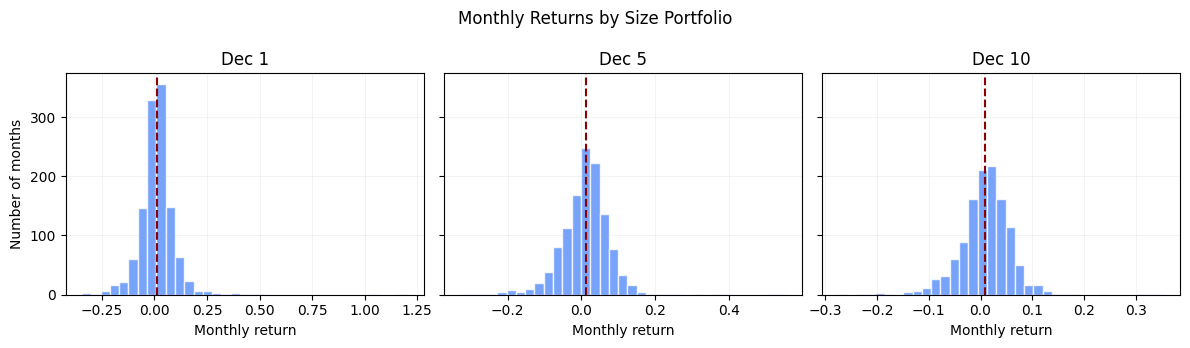

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for column, ax in zip(['Dec 1', 'Dec 5', 'Dec 10'], axes):
    ax.hist(portfolio_returns[column], bins=35, edgecolor='white', alpha=0.8)
    ax.axvline(portfolio_returns[column].mean(), color='darkred', linestyle='--')
    ax.set_title(column)
    ax.set_xlabel('Monthly return')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Number of months')
fig.suptitle('Monthly Returns by Size Portfolio')
fig.tight_layout()
plt.show()

## Plot cumulative wealth

If one dollar is invested at the beginning of the sample and all returns are reinvested, its value evolves according to

$$W_T = \prod_{t=1}^{T}(1+R_t).$$

This plot shows realized compound growth for decile 1 and decile 10 portfolios from 2000 to the most recent available observation. It should not be confused with the annualized arithmetic mean used in the summary table.

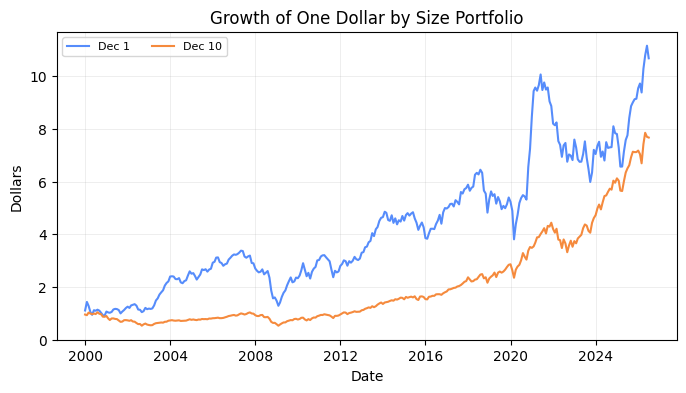

In [8]:
selected_portfolios = ['Dec 1', 'Dec 10']
size_returns = portfolio_returns.loc['2000-01-01':, selected_portfolios]
cumulative_wealth = (1 + size_returns).cumprod()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    cumulative_wealth.index.to_timestamp(),
    cumulative_wealth
)
ax.set_title('Growth of One Dollar by Size Portfolio')
ax.set_xlabel('Date')
ax.set_ylabel('Dollars')


# Linear y-axis with comma-formatted values
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.legend(size_returns.columns, ncol=3, fontsize=8)
ax.grid(alpha=0.3)

plt.show()

## Try it
Here are some additional exercises to practice the `load_ken_french_data()` function.

1. Filter the `available` DataFrame to display only strategies with daily data. Which strategies have published daily files?

2. Change the first example from `strategy='size'` to `strategy='momentum'` or `strategy='booktomarket'`. Compare the returned column names and dates.

3. Change `data_type='deciles'` to `data_type='quintiles'` for the book-to-market example. How does the number of portfolios change?

4. Change `weighting='equal'` to `weighting='value'` for `bm_portfolios`. How do the portfolio returns differ?

5. Change `portfolio=[1, 5]` to `portfolio='low'`, `portfolio='high'`, or `portfolio='all'`. What columns are returned in each case?

6. Add an `end_date` to the daily size request. How does restricting the sample period change the returned DataFrame?

7. Use `details=True` with another strategy. What information does the function provide about the source and portfolio construction?

8. Recalculate `summary_stats` using only `Dec 1`, `Dec 5`, and `Dec 10`.

9. Change the histogram from 35 bins to 15 and then 75 bins. How does the choice of bins affect your interpretation of the return distribution?

10. Change `selected_portfolios` in the cumulative-wealth example to `['Dec 1', 'Dec 5', 'Dec 10']`. How do the growth paths compare?

11. Try to request daily size quintiles using `data_type='quintiles'` and `frequency='daily'`. Read the error message and explain why the request is unavailable.
12. Try to request daily data for `strategy='accruals'`. Use the error message to identify the frequencies published for that strategy.
13. Try `data_type='quintiles'` with `strategy='momentum'`. Explain why the loader rejects the request instead of creating quintiles by averaging deciles.